In [83]:
import cga_utils
import prompt_versions
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [84]:
from langchain.globals import set_llm_cache
from langchain_community.cache import SQLiteCache

set_llm_cache(SQLiteCache(database_path=".langchain.ollama24_3.db"))

In [85]:
from langchain_community.chat_models import ChatOllama
llm = ChatOllama(model="qwen3:4b", temperature = 0.0, top_p = 1, repeat_penalty=1, presence_penalty=0, frequency_penalty=0)  # vagy bármely más elérhető Ollama modell

In [82]:
messages = prompt_versions.prompt_versions['V18']
messages = [(a, t.replace('/no_think','')) for (a,t)  in messages]
messages[-1] = ( messages[-1][0],  messages[-1][1] + "/no_think" ) 

res = cga_utils.execute_datset_predictions(llm, messages)

0it [00:00, ?it/s]

b2786c1a-37de-4120-b03c-32bf5c81f157
What was the change in the amount for Appliances in 2019 from 2018? Success: -94.0
<< 680-774 || [680.0, 774.0, -94.0] || [680.0, 774.0] || True >>
fe11f001-3bfe-4089-8108-412676f0a780
What was the percentage change in the amount for Appliances in 2019 from 2018? Success: -12.14
<< (680-774)/774 || [680.0, 774.0, -12.144702842377262] || [680.0, 774.0, 774.0] || True >>
5103aed0-b4e8-4fae-bf78-e2c9f4ba84cf
What is the difference between the domestic and international discount rates as at September 30, 2019? Success: 2.1
<< 4.00 - 1.90  || [4.0, 1.9] || [4.0, 1.9] || True >>
4dc8be43-d8d9-4b08-9ffd-9c19012361ce
What is the year on year percentage change in domestic discount rate between 2018 and 2019? Success: 6.67
<< (4.00 - 3.75)/3.75  || [3.75, 4.0, 6.666666666666667] || [4.0, 3.75, 3.75] || True >>
6c44a1a8-0785-43a0-90ab-7e21df2c57d9
What is the year on year percentage change in international expected return on plan assets between 2018 and 2019? 

In [62]:
annotated_results = cga_utils.annotate_results(res)
#annotated_results.to_csv('res/Ollama_2_gemma3n_e4b_code_values_v11_m1.csv')
cga_utils.calc_overall_value_match(annotated_results)

0.7670103092783506


In [63]:
cga_utils.calc_overall_em(annotated_results)

0.6041237113402061


In [64]:
annotated_results

,qid,question,derivation,calc_pattern,pred,pred_scale,answer,scale,value_match,selection_success,sign_error,is_parenth_in_table,has_code_abs,error_text,value_list,code,selected_values,needed_values,exact_match,error_code
0,b2786c1a-37de-4120-b03c-32bf5c81f157,What was the change in the amount for Applianc...,680-774,#-#,-94.0,million,-94.00,million,True,True,False,False,False,,"[{'number_value': 5686.0, 'scale': 'million', ...",def run(value_list):\n for item in value_li...,"[680.0, 774.0, -94.0]","[680.0, 774.0]",True,none
1,fe11f001-3bfe-4089-8108-412676f0a780,What was the percentage change in the amount f...,(680-774)/774,(#-#)/#,-12.14,percent,-12.14,percent,True,True,False,False,False,,"[{'number_value': 5686.0, 'scale': 'million', ...",def run(value_list):\n # Filter for Applian...,"[680.0, 774.0, -12.144702842377262]","[680.0, 774.0, 774.0]",True,none
2,5103aed0-b4e8-4fae-bf78-e2c9f4ba84cf,What is the difference between the domestic an...,4.00 - 1.90,#-#,2.1,percent,2.10,percent,True,True,False,False,False,,"[{'number_value': 4.0, 'scale': '%', 'category...",def run(value_list):\n domestic_2019 = None...,"[4.0, 1.9]","[4.0, 1.9]",True,none
3,4dc8be43-d8d9-4b08-9ffd-9c19012361ce,What is the year on year percentage change in ...,(4.00 - 3.75)/3.75,(#-#)/#,6.67,percent,6.67,percent,True,True,False,False,False,,"[{'number_value': 4.0, 'scale': '%', 'category...",def run(value_list):\n domestic_2018 = None...,"[3.75, 4.0, 6.666666666666667]","[4.0, 3.75, 3.75]",True,none
4,6c44a1a8-0785-43a0-90ab-7e21df2c57d9,What is the year on year percentage change in ...,(3.40 - 3.70)/3.70,(#-#)/#,-8.11,percent,-8.11,percent,True,True,False,False,False,,"[{'number_value': 4.0, 'scale': '%', 'category...",def run(value_list):\n # Filter for 'Expect...,"[3.7, 3.4, -8.108108108108116]","[3.4, 3.7, 3.7]",True,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480,c8ed0bf6-60c5-41e2-97e3-5ece54a1349b,What is the change in total personnel expenses...,"227,727 - 188,503",#-#,39224.0,,39224.00,,True,True,False,False,False,,"[{'number_value': 158371.0, 'scale': '', 'cate...",def run(value_list):\n total_2018 = next(it...,"[188503.0, 227727.0, 39224.0]","[227727.0, 188503.0]",True,none
481,4cdc8b2e-e3ea-4c36-bbda-7c409a84cc78,What is the percentage change in total personn...,"(227,727 - 188,503 )/188,503",(#-#)/#,20.81,percent,20.81,percent,True,True,False,False,False,,"[{'number_value': 158371.0, 'scale': '', 'cate...",def run(value_list):\n total_2018 = next(it...,"[188503.0, 227727.0, 20.80815689935969]","[227727.0, 188503.0, 188503.0]",True,none
482,ec696158-f93d-4608-903d-a6b9c4e7bfd5,What is the increase / (decrease) in the telec...,86.8 - 87.0,#-#,-0.2,million,-0.20,million,True,True,False,False,False,,"[{'number_value': 86.8, 'scale': '', 'category...",def run(value_list):\n telecomm_maintenance...,"[87.0, 86.8, -0.20000000000000284]","[86.8, 87.0]",True,none
483,27911d6f-dfe5-487b-bc56-7e5cf16a32e0,What is the average telecommunications install...,(33.2 + 41.5) / 2,(#+#)/#,37.35,million,37.35,million,True,True,False,False,False,,"[{'number_value': 86.8, 'scale': '', 'category...",def run(value_list):\n telecomm_installatio...,"[33.2, 41.5, 37.35]","[33.2, 41.5]",True,none


In [65]:
annotated_results.to_csv('res/e37.csv')

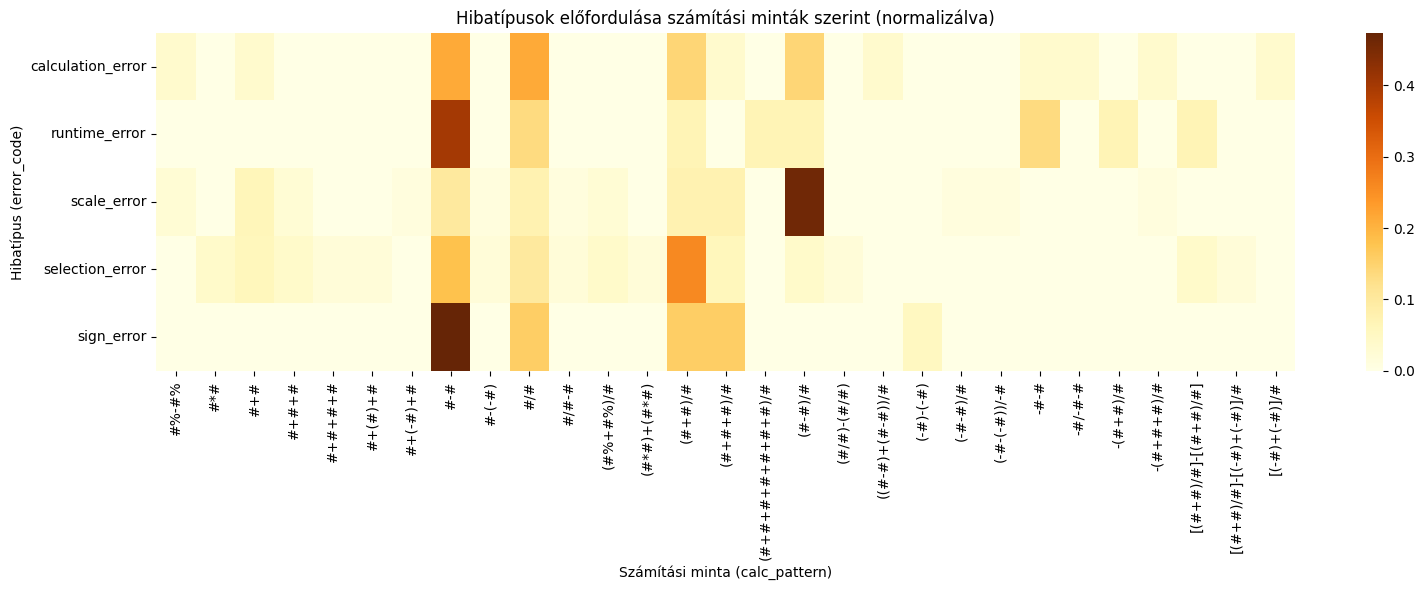

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = annotated_results.query('error_code != "none"')
# 1. Kontingenciatábla: hányszor fordul elő egy hibatípus egy adott mintánál
pattern_error_matrix = pd.crosstab(df['error_code'], df['calc_pattern'])

# 2. (Opcionális) Normalizálás soronként: egy hibatípus milyen mintákban dominál
normalized = pattern_error_matrix.div(pattern_error_matrix.sum(axis=1), axis=0)

# 3. Hőtérkép
plt.figure(figsize=(16, 6))
sns.heatmap(normalized, cmap='YlOrBr', annot=False)

plt.title("Hibatípusok előfordulása számítási minták szerint (normalizálva)")
plt.xlabel("Számítási minta (calc_pattern)")
plt.ylabel("Hibatípus (error_code)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


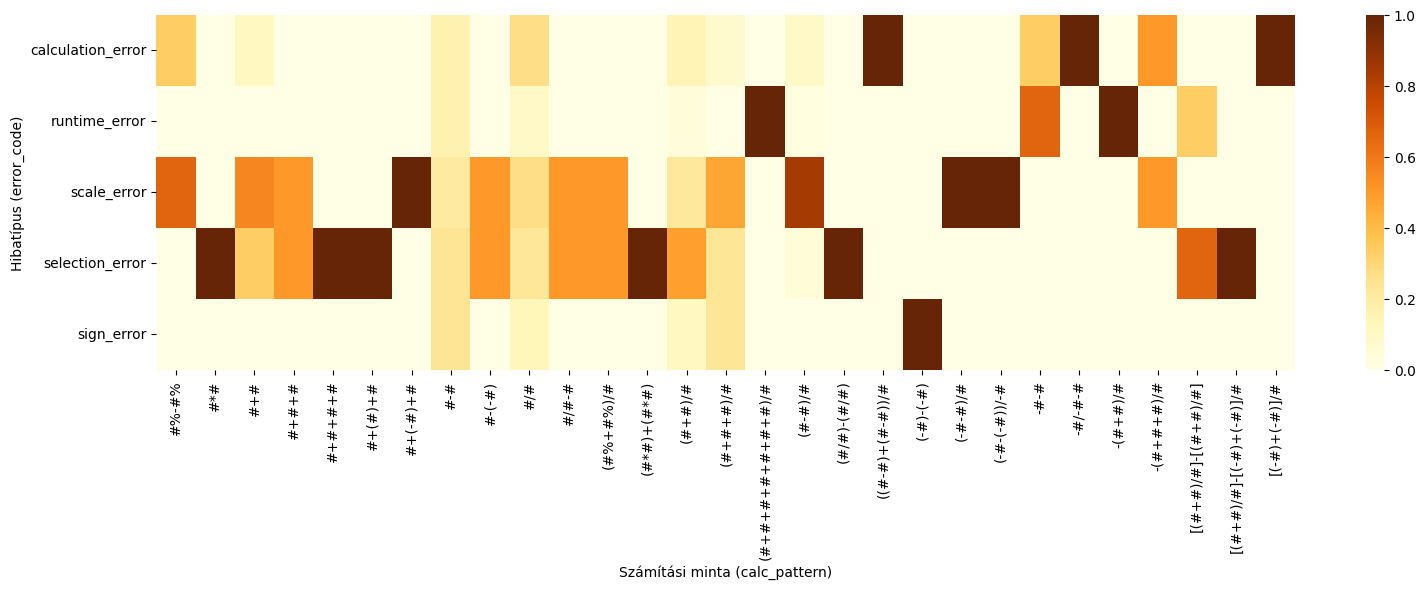

In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = annotated_results.query('error_code != "none"')
# 1. Kontingenciatábla: hányszor fordul elő egy hibatípus egy adott mintánál
pattern_error_matrix = pd.crosstab(df['error_code'], df['calc_pattern'])

normalized_col = pattern_error_matrix.div(pattern_error_matrix.sum(axis=0), axis=1)

# 3. Hőtérkép
plt.figure(figsize=(16, 6))
sns.heatmap(normalized_col, cmap='YlOrBr', annot=False)

#plt.title("Hibatípusok előfordulása számítási minták szerint (normalizálva)")
plt.xlabel("Számítási minta (calc_pattern)")
plt.ylabel("Hibatípus (error_code)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


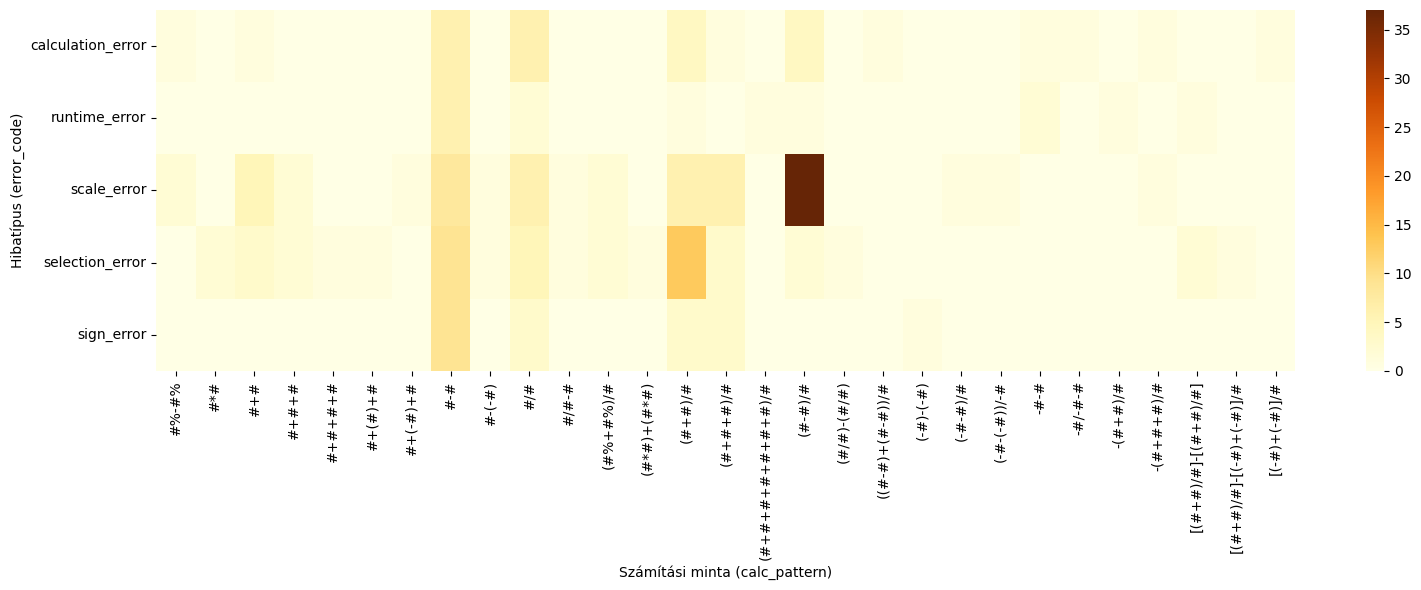

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = annotated_results.query('error_code != "none"')
# 1. Kontingenciatábla: hányszor fordul elő egy hibatípus egy adott mintánál
pattern_error_matrix = pd.crosstab(df['error_code'], df['calc_pattern'])

# 3. Hőtérkép
plt.figure(figsize=(16, 6))
sns.heatmap(pattern_error_matrix, cmap='YlOrBr', annot=False)

#plt.title("Hibatípusok előfordulása számítási minták szerint (normalizálva)")
plt.xlabel("Számítási minta (calc_pattern)")
plt.ylabel("Hibatípus (error_code)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

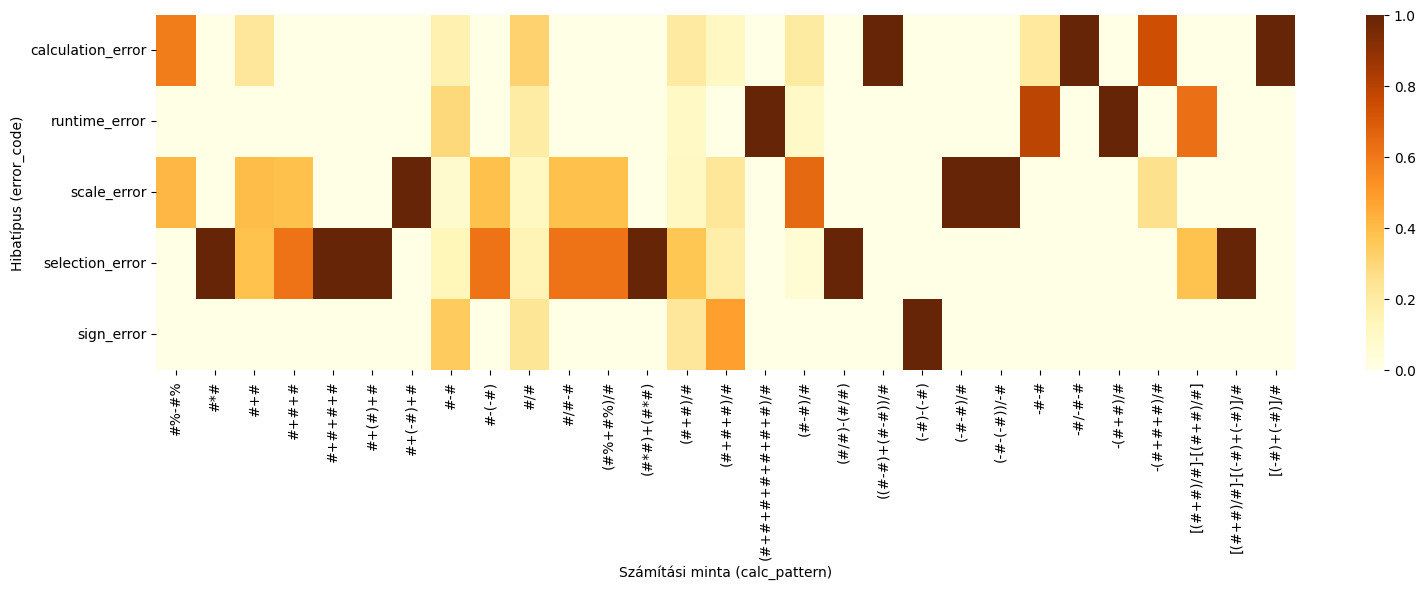

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = annotated_results.query('error_code != "none"')
# 1. Kontingenciatábla: hányszor fordul elő egy hibatípus egy adott mintánál
pattern_error_matrix = pd.crosstab(df['error_code'], df['calc_pattern'])

step1 = pattern_error_matrix.div(pattern_error_matrix.sum(axis=1), axis=0)  # soronként
step2 = step1.div(step1.sum(axis=0), axis=1)  # majd oszloponként az eredményen


# 3. Hőtérkép
plt.figure(figsize=(16, 6))
sns.heatmap(step2, cmap='YlOrBr', annot=False)

#plt.title("Hibatípusok előfordulása számítási minták szerint (normalizálva)")
plt.xlabel("Számítási minta (calc_pattern)")
plt.ylabel("Hibatípus (error_code)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

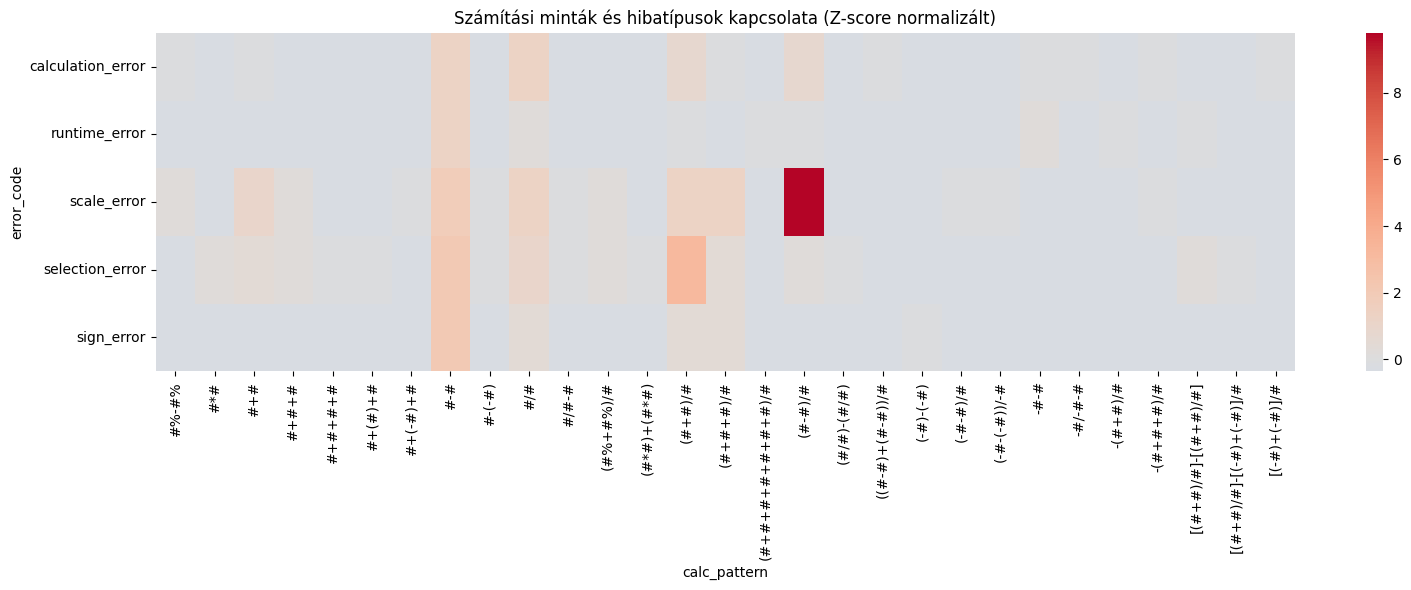

In [80]:
from scipy.stats import zscore
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = annotated_results.query('error_code != "none"')

# 1. Kontingenstábla létrehozása
pattern_error_matrix = pd.crosstab(df['error_code'], df['calc_pattern'])

# 2. Mátrix szintű Z-score (numpy-n keresztül)
z_values = zscore(pattern_error_matrix.values.flatten())
z_matrix = z_values.reshape(pattern_error_matrix.shape)

# 3. DataFrame visszaépítése
z_df = pd.DataFrame(z_matrix, index=pattern_error_matrix.index, columns=pattern_error_matrix.columns)

# 4. Hőtérkép
plt.figure(figsize=(16, 6))
sns.heatmap(z_df, cmap="coolwarm", center=0)

plt.title("Számítási minták és hibatípusok kapcsolata (Z-score normalizált)")
plt.xlabel("calc_pattern")
plt.ylabel("error_code")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


<Axes: xlabel='calc_pattern', ylabel='error_code'>

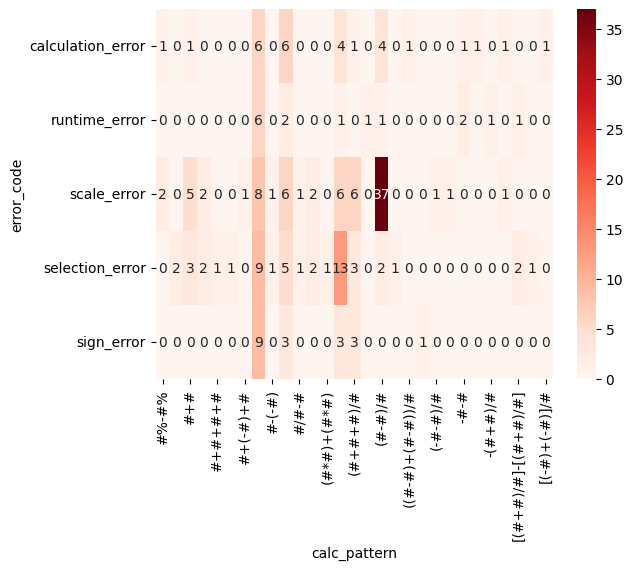

In [75]:
sns.heatmap(pattern_error_matrix, cmap='Reds', annot=True, fmt="d")


#### code snippets

In [18]:
annotated_results.iloc[484]['code']

"def run(value_list):\n    total = 0.0\n    count = 0\n    for item in value_list:\n        if item['category'] == 'Total Marine Services segment revenue':\n            total += item['number_value']\n            count += 1\n    if count == 0:\n        return (0.0, '')\n    average = total / count\n    return (round(average, 2), '')"

In [ ]:
import pandas as pd
[i for i in pd.DataFrame(res)[7] if i != '']